### References

https://github.com/gabrielziegler3/xgboost-multiclass-multilabel/blob/master/xgboost-multiclass/multiclass-frog-classification.ipynb


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [2]:
data = pd.read_csv("../ml_cp18//ml_cp18.csv")
data.describe()

,bid_size,ask_size,last_size,volume,bid_ask_delta,c_w1_n3_bid_ask_delta,c_w1_n3_ask,c_w1_n3_ask_size,c_w1_n3_bid,c_w1_n3_bid_size,...,c_w3_p3_bid_ask_delta,c_w3_p3_ask,c_w3_p3_ask_size,c_w3_p3_bid,c_w3_p3_bid_size,c_w3_p3_last,c_w3_p3_last_size,c_w3_p3_strike_delta,c_w3_p3_time_value,c_w3_p3_theta
count,23242.000000,23242.000000,23242.000000,2.324200e+04,23242.000000,23221.000000,23221.000000,23221.000000,23221.000000,23221.000000,...,22174.000000,22174.000000,22174.000000,22174.000000,22174.000000,22174.000000,22174.000000,22174.000000,22174.000000,22174.000000
mean,11.419069,12.619482,2.640134,5.780484e+05,-0.014356,-0.143011,6.097166,494.951079,5.954156,485.349813,...,-0.015615,1.734052,309.164472,1.718437,310.170109,1.725193,5.124876,-6.562156,8.288400,3.382115
std,10.074586,11.660392,4.716379,2.641619e+05,0.006119,0.059762,0.749796,433.432503,0.744555,418.485218,...,0.006295,0.223913,218.122760,0.223012,221.916924,0.224407,9.604160,0.738582,0.560458,0.273981
min,1.000000,1.000000,1.000000,2.010500e+04,-0.170000,-2.400000,-1.000000,0.000000,-1.000000,0.000000,...,-0.210000,-1.000000,0.000000,-1.000000,0.000000,1.270000,1.000000,-7.490000,4.660000,1.991453
25%,4.000000,5.000000,1.000000,3.556430e+05,-0.020000,-0.150000,5.450000,141.000000,5.300000,166.000000,...,-0.020000,1.600000,137.000000,1.580000,126.000000,1.590000,1.000000,-7.180000,7.890000,3.181410
50%,9.000000,11.000000,1.000000,6.253780e+05,-0.010000,-0.150000,5.950000,377.000000,5.800000,392.000000,...,-0.020000,1.680000,283.000000,1.660000,273.000000,1.670000,1.000000,-6.750000,8.410000,3.380475
75%,16.000000,18.000000,2.000000,8.034665e+05,-0.010000,-0.150000,6.650000,754.000000,6.500000,699.000000,...,-0.010000,1.810000,465.000000,1.790000,472.000000,1.807500,5.000000,-6.080000,8.760000,3.639713
max,375.000000,443.000000,144.000000,1.026599e+06,0.000000,0.000000,8.900000,3351.000000,7.550000,3211.000000,...,0.000000,2.400000,3242.000000,2.380000,1161.000000,2.400000,175.000000,-5.000000,9.125000,3.848915


In [3]:
data.head(3)

,bid_size,ask_size,last_size,volume,bid_ask_delta,c_w1_n3_bid_ask_delta,c_w1_n3_ask,c_w1_n3_ask_size,c_w1_n3_bid,c_w1_n3_bid_size,...,c_w3_p3_ask_size,c_w3_p3_bid,c_w3_p3_bid_size,c_w3_p3_last,c_w3_p3_last_size,c_w3_p3_strike_delta,c_w3_p3_time_value,c_w3_p3_theta,p60s_bucket_category,p300s_bucket_category
0,2.0,4.0,1.0,20105.0,-0.06,-0.70,7.05,1.0,6.35,101.0,...,9.0,1.52,9.0,1.66,4.0,-6.01,7.555,2.935120,NaN,NaN
1,2.0,6.0,1.0,20193.0,-0.04,-1.05,7.10,3.0,6.05,1.0,...,30.0,1.54,44.0,1.66,4.0,-5.98,7.545,2.931235,NaN,NaN
2,6.0,1.0,2.0,20196.0,-0.02,-1.30,7.35,1.0,6.05,1.0,...,13.0,1.56,21.0,1.57,1.0,-5.94,7.520,2.921523,NaN,NaN


In [4]:
data = data.dropna()
#data = data.head(1000)


In [5]:
cols = data.columns.values.tolist()
cols

['bid_size',
 'ask_size',
 'last_size',
 'volume',
 'bid_ask_delta',
 'c_w1_n3_bid_ask_delta',
 'c_w1_n3_ask',
 'c_w1_n3_ask_size',
 'c_w1_n3_bid',
 'c_w1_n3_bid_size',
 'c_w1_n3_last',
 'c_w1_n3_last_size',
 'c_w1_n3_strike_delta',
 'c_w1_n3_time_value',
 'c_w1_n3_theta',
 'c_w1_n2_bid_ask_delta',
 'c_w1_n2_ask',
 'c_w1_n2_ask_size',
 'c_w1_n2_bid',
 'c_w1_n2_bid_size',
 'c_w1_n2_last',
 'c_w1_n2_last_size',
 'c_w1_n2_strike_delta',
 'c_w1_n2_time_value',
 'c_w1_n2_theta',
 'c_w1_n1_bid_ask_delta',
 'c_w1_n1_ask',
 'c_w1_n1_ask_size',
 'c_w1_n1_bid',
 'c_w1_n1_bid_size',
 'c_w1_n1_last',
 'c_w1_n1_last_size',
 'c_w1_n1_strike_delta',
 'c_w1_n1_time_value',
 'c_w1_n1_theta',
 'c_w1_p1_bid_ask_delta',
 'c_w1_p1_ask',
 'c_w1_p1_ask_size',
 'c_w1_p1_bid',
 'c_w1_p1_bid_size',
 'c_w1_p1_last',
 'c_w1_p1_last_size',
 'c_w1_p1_strike_delta',
 'c_w1_p1_time_value',
 'c_w1_p1_theta',
 'c_w1_p2_bid_ask_delta',
 'c_w1_p2_ask',
 'c_w1_p2_ask_size',
 'c_w1_p2_bid',
 'c_w1_p2_bid_size',
 'c_w1_p2_l

In [6]:
X = data.drop(['p60s_bucket_category', 'p300s_bucket_category'], axis=1)
Y = data[['p300s_bucket_category']]


In [7]:
X.shape


(19721, 185)

In [8]:
categories = Y.p300s_bucket_category.unique().tolist()
Y

,p300s_bucket_category
1217,q_6_1.18
1218,q_5_0.36
1219,q_5_0.36
1220,q_5_0.36
1221,q_5_0.36
...,...
23237,q_6_1.18
23238,q_6_1.18
23239,q_6_1.18
23240,q_6_1.18


In [9]:
from sklearn.model_selection import train_test_split
X15_train, X15_test, y15_train, y15_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [10]:
from datetime import datetime
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from xgboost.sklearn import XGBClassifier

start_time = datetime.now()
# From Sagemaker tuning
parameters = {'_kfold': '5',
              '_tuning_objective_metric': 'validation:accuracy',
              'objective': 'validation:accuracy',
              
              'alpha': 0.029064625217569095,
              'colsample_bytree': 0.5300674649920706,
              'eta': 0.06785230577839381,
              'eval_metric': 'accuracy,f1',
              'gamma': 8.822571607235765e-06,
              'lambda': 2.236266181542945e-06,
              'max_depth': 8,
              'min_child_weight': 5.3334410483799005e-05,
              'num_class': 9,
              'num_round': 855,
              'objective': 'multi:softprob',
              'subsample': 0.7607022674051444}

xgb15 = XGBClassifier(objective='multi:softprob', eval_metric='merror',
            gamma=0.000008822571607235765, #8.822571607235765e-06,
            min_child_weight=5.3334410483799005e-05,
            num_class=7,
            #'lambda'=0.000002236266181542945, #2.236266181542945e-06,
            max_depth=8
)

xgb15.fit(X15_train, y15_train)

stop_time = datetime.now()

/Users/Muthu/Development/OptionList4/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/Muthu/Development/OptionList4/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Muthu/Development/OptionList4/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for

In [11]:
print(xgb15)


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='merror', gamma=8.822571607235765e-06, gpu_id=-1,
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_delta_step=0, max_depth=8,
              min_child_weight=5.3334410483799005e-05, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=10,
              num_class=7, num_parallel_tree=1, objective='multi:softprob',
              predictor='auto', random_state=0, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=None, subsample=1, tree_method='exact',
              validate_parameters=1, ...)


In [12]:
print('Start Timestamp : ', start_time.strftime("%d-%b-%Y (%H:%M:%S.%f)"))
print('Stop Timestamp : ', stop_time.strftime("%d-%b-%Y (%H:%M:%S.%f)"))
import math
td = stop_time - start_time
td_mins = int(math.floor((td).total_seconds() / 60))
td_secs = td.total_seconds() - int(math.floor((td).total_seconds() / 60)*60)
print(f'The difference is approx. {td_mins}:{td_secs:02.0f} (min:sec)')


Start Timestamp :  22-Dec-2021 (14:36:39.289277)
Stop Timestamp :  22-Dec-2021 (14:37:10.140912)
The difference is approx. 0:31 (min:sec)


In [13]:
pred = xgb15.predict(X15_test)

from sklearn.metrics import accuracy_score
print(accuracy_score( y15_test, pred ) )

0.8446134347275032


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y15_test, pred, target_names=categories))

              precision    recall  f1-score   support

    q_6_1.18       0.93      0.97      0.95       544
    q_5_0.36       0.85      0.83      0.84       572
    q_4_0.17       0.83      0.80      0.81       620
    q_3_0.04       0.75      0.78      0.77       531
   q_2_-0.08       0.78      0.77      0.77       556
   q_1_-0.22       0.84      0.85      0.85       593
   q_0_-0.42       0.94      0.93      0.94       529

    accuracy                           0.84      3945
   macro avg       0.85      0.85      0.85      3945
weighted avg       0.84      0.84      0.84      3945



In [15]:
def plot_confusion_matrix(cm, classes, normalized=True, cmap='bone', fmt='g'):
    plt.figure(figsize=[7, 6])
    norm_cm = cm
    if normalized:
        norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(norm_cm, annot=cm, fmt=fmt, xticklabels=classes, yticklabels=classes, cmap=cmap)

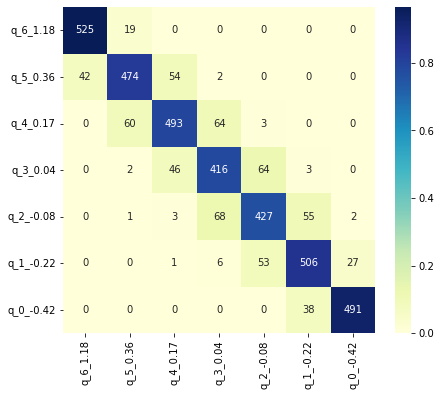

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pylab as plt
import seaborn as sns
import xgboost as xgb

frog_cm = confusion_matrix(y15_test, pred)
plot_confusion_matrix(frog_cm, classes=categories, cmap='YlGnBu')


In [17]:
frog_cm_pct = frog_cm.astype('float') / frog_cm.sum(axis=1)[:, np.newaxis]

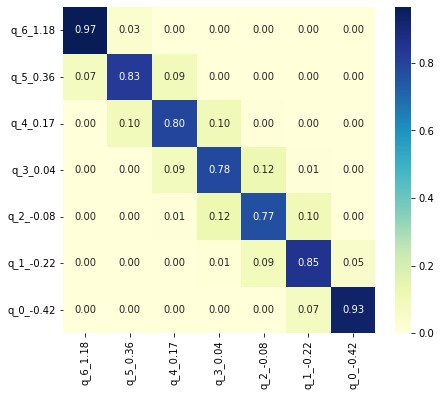

In [18]:
plot_confusion_matrix(frog_cm_pct, fmt='.2f', cmap='YlGnBu', classes=categories)


In [19]:
file="models/dec19-xgboost" +  datetime.now().strftime("-%Y%m%d-%H%M%S") +".json"
xgb15.save_model(file)
file

XGBoostError: [14:37:11] /Users/runner/work/xgboost/xgboost/dmlc-core/src/io/local_filesys.cc:209: Check failed: allow_null:  LocalFileSystem::Open "models/dec19-xgboost-20211222-143711.json": No such file or directory
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x000000014b34a814 dmlc::LogMessageFatal::~LogMessageFatal() + 116
  [bt] (1) 2   libxgboost.dylib                    0x000000014b54737c dmlc::io::LocalFileSystem::Open(dmlc::io::URI const&, char const*, bool) + 876
  [bt] (2) 3   libxgboost.dylib                    0x000000014b52c28e dmlc::Stream::Create(char const*, char const*, bool) + 62
  [bt] (3) 4   libxgboost.dylib                    0x000000014b344860 XGBoosterSaveModel + 112
  [bt] (4) 5   libffi.dylib                        0x00007ff811466a05 ffi_call_unix64 + 85
  [bt] (5) 6   ???                                 0x0000000302988ff0 0x0 + 12928454640



In [20]:
frog_cm

array([[525,  19,   0,   0,   0,   0,   0],
       [ 42, 474,  54,   2,   0,   0,   0],
       [  0,  60, 493,  64,   3,   0,   0],
       [  0,   2,  46, 416,  64,   3,   0],
       [  0,   1,   3,  68, 427,  55,   2],
       [  0,   0,   1,   6,  53, 506,  27],
       [  0,   0,   0,   0,   0,  38, 491]])

In [29]:
np.set_printoptions(precision=2)
frog_cm_pct

array([[0.97, 0.03, 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.07, 0.83, 0.09, 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.1 , 0.8 , 0.1 , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.09, 0.78, 0.12, 0.01, 0.  ],
       [0.  , 0.  , 0.01, 0.12, 0.77, 0.1 , 0.  ],
       [0.  , 0.  , 0.  , 0.01, 0.09, 0.85, 0.05],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.07, 0.93]])

In [30]:
print(xgb15.feature_importances_)


[6.19e-04 7.99e-04 7.14e-04 1.08e-02 7.76e-04 7.85e-04 1.33e-03 1.14e-03
 2.40e-03 1.22e-03 1.36e-02 1.24e-02 3.60e-03 1.14e-03 1.26e-03 1.75e-03
 1.44e-03 1.27e-03 3.22e-03 1.46e-03 1.31e-02 6.52e-03 0.00e+00 1.18e-02
 1.87e-03 8.03e-04 4.96e-03 1.37e-03 1.16e-02 1.58e-03 1.44e-02 3.38e-03
 0.00e+00 4.99e-03 4.22e-03 1.48e-03 1.04e-02 1.83e-03 1.33e-02 2.55e-03
 7.68e-03 2.22e-03 0.00e+00 1.04e-02 5.41e-03 4.18e-05 7.21e-03 4.78e-03
 3.81e-02 6.47e-03 6.84e-03 3.70e-03 0.00e+00 1.48e-02 6.82e-03 0.00e+00
 7.17e-03 7.96e-03 0.00e+00 7.60e-03 5.15e-03 5.66e-03 0.00e+00 8.33e-03
 1.31e-02 5.46e-03 9.74e-03 2.06e-03 9.74e-03 1.99e-03 1.76e-02 1.51e-02
 0.00e+00 3.28e-03 5.56e-03 1.02e-02 5.54e-03 3.05e-03 6.82e-03 2.92e-03
 2.12e-02 1.05e-02 0.00e+00 4.55e-03 3.61e-03 3.63e-03 2.35e-03 1.82e-03
 7.72e-03 2.04e-03 7.15e-03 5.78e-03 0.00e+00 3.08e-03 5.54e-03 8.34e-03
 4.62e-03 1.53e-03 4.44e-03 1.90e-03 1.07e-02 3.51e-03 0.00e+00 4.48e-03
 3.74e-03 1.20e-03 6.86e-03 1.58e-03 6.94e-03 1.42e

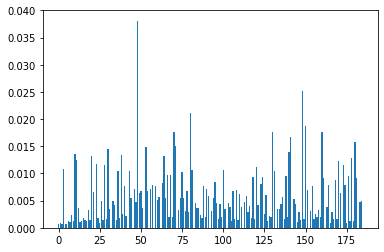

In [24]:
# plot
from matplotlib import pyplot
pyplot.bar(range(len(xgb15.feature_importances_)), xgb15.feature_importances_)
pyplot.show()

In [32]:
features = xgb15.get_booster().feature_names

In [34]:
importance = xgb15.feature_importances_
# summarize feature importance
for i,v in enumerate(importance):
	print('%0d:\t%s\t%.6f'%(i, features[i], v))

0:	bid_size	0.000619
1:	ask_size	0.000799
2:	last_size	0.000714
3:	volume	0.010849
4:	bid_ask_delta	0.000776
5:	c_w1_n3_bid_ask_delta	0.000785
6:	c_w1_n3_ask	0.001327
7:	c_w1_n3_ask_size	0.001142
8:	c_w1_n3_bid	0.002396
9:	c_w1_n3_bid_size	0.001223
10:	c_w1_n3_last	0.013625
11:	c_w1_n3_last_size	0.012421
12:	c_w1_n3_strike_delta	0.003599
13:	c_w1_n3_time_value	0.001138
14:	c_w1_n3_theta	0.001264
15:	c_w1_n2_bid_ask_delta	0.001748
16:	c_w1_n2_ask	0.001435
17:	c_w1_n2_ask_size	0.001274
18:	c_w1_n2_bid	0.003219
19:	c_w1_n2_bid_size	0.001465
20:	c_w1_n2_last	0.013140
21:	c_w1_n2_last_size	0.006516
22:	c_w1_n2_strike_delta	0.000000
23:	c_w1_n2_time_value	0.011760
24:	c_w1_n2_theta	0.001869
25:	c_w1_n1_bid_ask_delta	0.000803
26:	c_w1_n1_ask	0.004964
27:	c_w1_n1_ask_size	0.001373
28:	c_w1_n1_bid	0.011625
29:	c_w1_n1_bid_size	0.001578
30:	c_w1_n1_last	0.014449
31:	c_w1_n1_last_size	0.003378
32:	c_w1_n1_strike_delta	0.000000
33:	c_w1_n1_time_value	0.004989
34:	c_w1_n1_theta	0.004223
35:	c_w1_p1